In [1]:
from calculate_entropy import *
import itertools
import numpy as np

In [2]:
ALGORITHMS_OF_INTEREST = ["JADE", "OriginalDE",
                        "SADE", "OriginalSHADE",
                        "ModifiedAEO","OriginalAEO", 
                        "AugmentedAEO"]
ALGORITHMS_OF_INTEREST2 = ["HI_WOA", 
                        "OriginalWOA", "GWO_WOA", 
                        "OriginalGWO", "IGWO", "RW_GWO"]

FUNCTION_GROUPS = {
    'separable': [1, 2, 3, 4, 5],
    'low_conditioning': [6, 7, 8, 9],
    'high_conditioning': [10, 11, 12, 13, 14],
    'multimodal_adequate': [15, 16, 17, 18, 19],
    'multimodal_weak': [20, 21, 22, 23, 24]
}
DIMENSIONS = [2, 5, 10]
FUNCTIONS = [i for i in range(1, 25)]
INSTANCES = [i for i in range(1, 6)]
INPUT_DIR = 'data/clustering_features_20_algorithms_kmeans/cluster_distributions'
OUTPUT_DIR = 'figures_entropy/comparison'


In [3]:
def visualize_single_problem(function, instance, dimensions, algs = ALGORITHMS_OF_INTEREST):
    for d in dimensions:
        input_dir = f'{INPUT_DIR}/dim_{d}/F{function}_I{instance}.csv'
        entropy = compute_entropy(input_dir, algorithms_of_interest=algs)
        plot_entropy(entropy, function, instance, d)

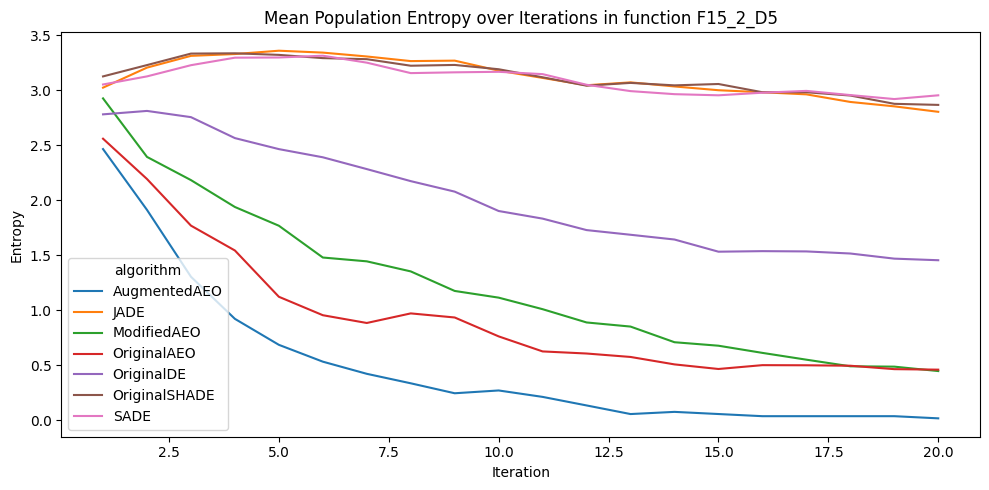

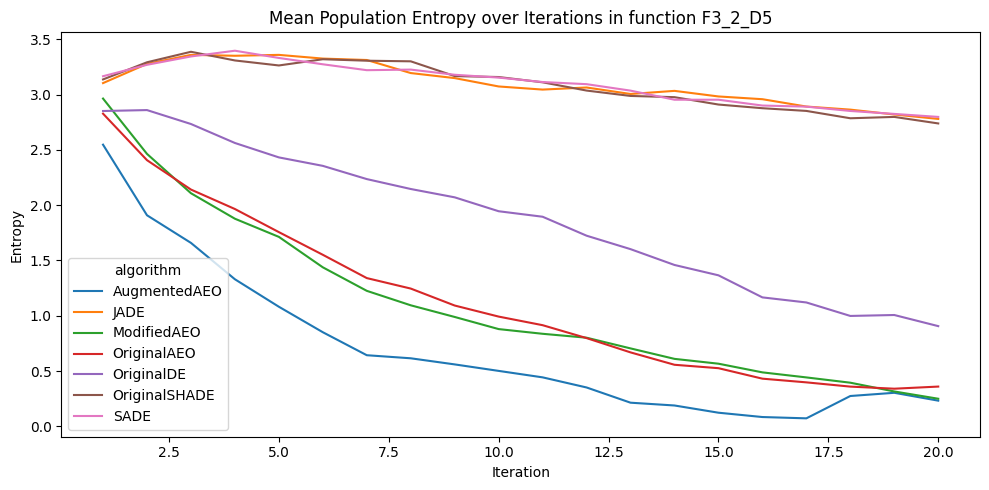

In [4]:
visualize_single_problem(15, 2, [5])
visualize_single_problem(3, 2, [5])

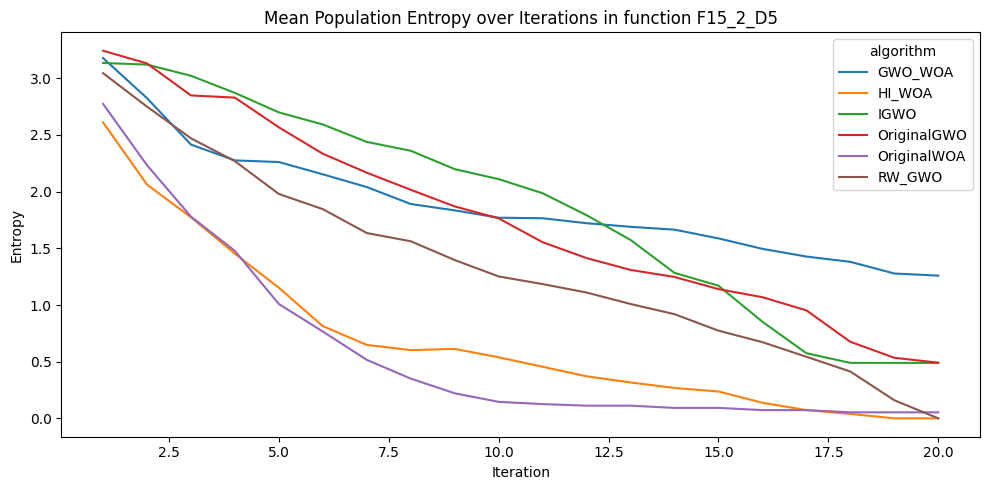

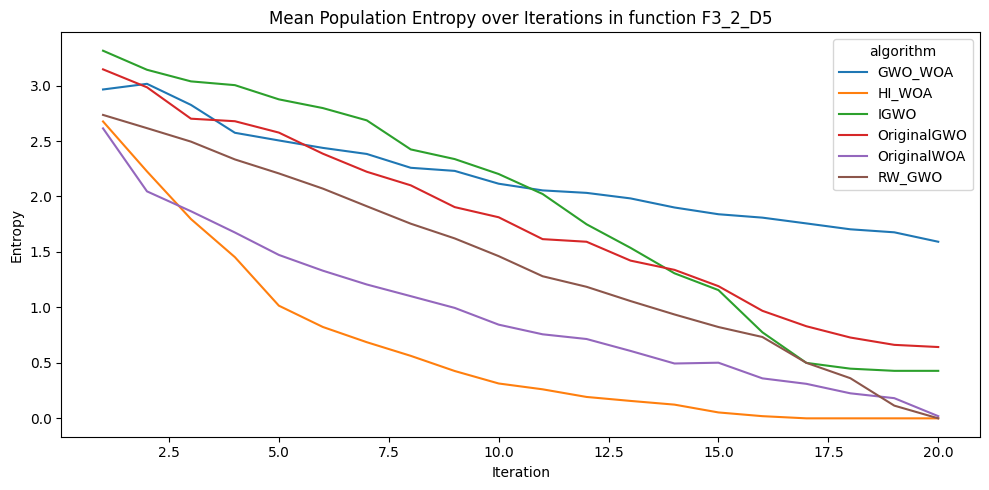

In [5]:
visualize_single_problem(15, 2, [5], algs=ALGORITHMS_OF_INTEREST2)
visualize_single_problem(3, 2, [5], algs=ALGORITHMS_OF_INTEREST2)

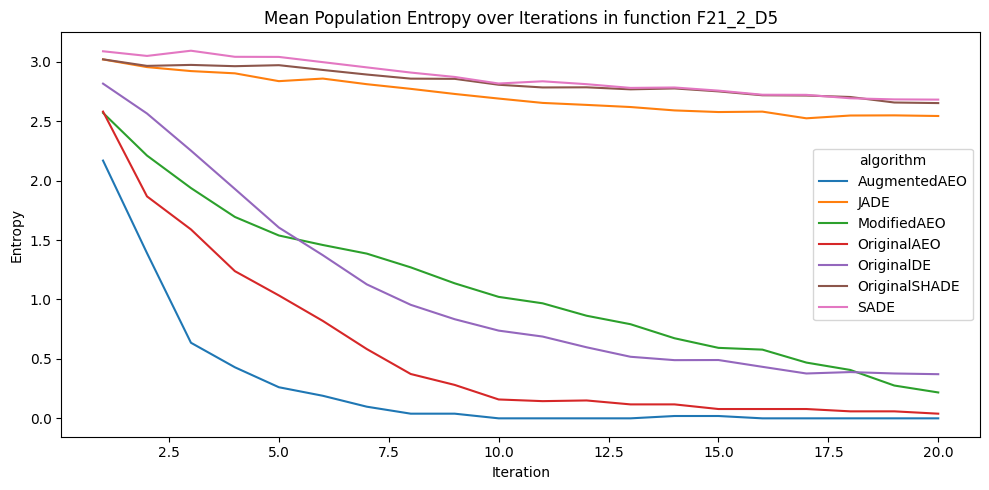

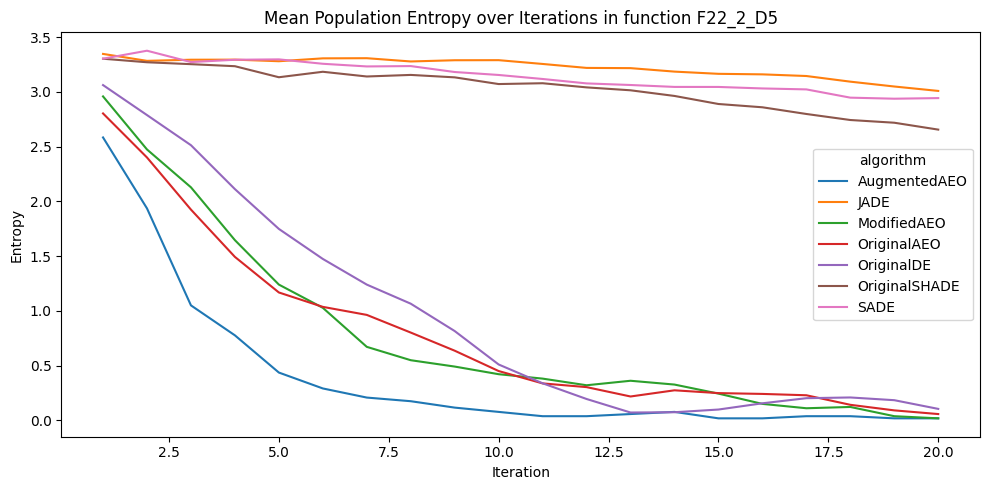

In [6]:
visualize_single_problem(21, 2, [5])
visualize_single_problem(22, 2, [5])

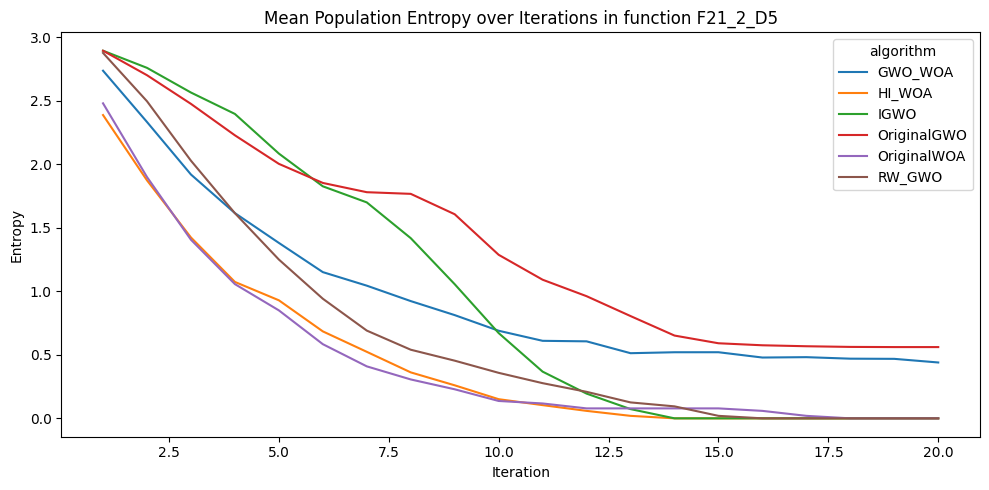

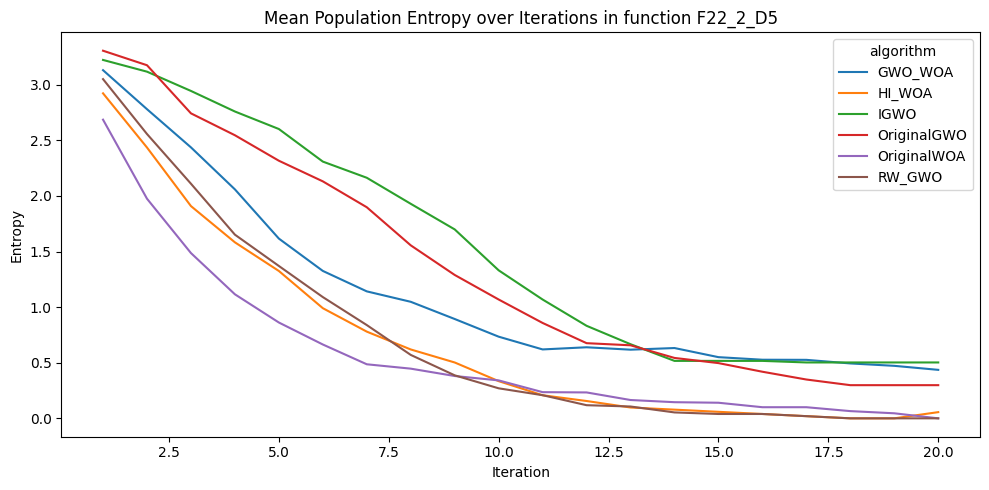

In [7]:
visualize_single_problem(21, 2, [5], algs=ALGORITHMS_OF_INTEREST2)
visualize_single_problem(22, 2, [5], algs=ALGORITHMS_OF_INTEREST2)

In [8]:
def compute_entropy_diff_matrix(filepath, algorithms_of_interest, runs=5):
    df = compute_entropy(filepath, algorithms_of_interest=algorithms_of_interest)
    pairs = itertools.combinations(algorithms_of_interest, 2)
    results = []
    
    for alg1, alg2 in pairs:
        runs_total = 0
        for run in range(1, runs + 1):
            data1 = df[(df['algorithm'] == alg1) & (df['run'] == run)]['entropy'].values
            data2 = df[(df['algorithm'] == alg2) & (df['run'] == run)]['entropy'].values
            runs_total += np.abs(data1 - data2).sum()
        results.append({
            'alg1': alg1,
            'alg2': alg2,
            'mean_entropy_diff': runs_total / runs
        })

    results_df = pd.DataFrame(results)
    algo_order = sorted(algorithms_of_interest)
    matrix = pd.DataFrame(index=algo_order, columns=algo_order, dtype=float)

    for _, row in results_df.iterrows():
        matrix.loc[row['alg1'], row['alg2']] = row['mean_entropy_diff']
        matrix.loc[row['alg2'], row['alg1']] = row['mean_entropy_diff']

    for alg in algo_order:
        matrix.loc[alg, alg] = 0.0

    return matrix

In [9]:
def plot_entropy_diff(matrix, output_dir=None, dimension=None, save=False):
    sns.set_theme(font_scale=0.8)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
    plt.title(f'Mean Entropy Difference between Algorithm Pairs (dim={dimension})')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save and output_dir is not None:
        plt.savefig(f'{output_dir}/entropy_diff_dim_{dimension}.pdf', bbox_inches='tight', pad_inches=0.2)
    else:
        plt.show()
    sns.set_theme(font_scale=1)
    plt.close()

In [11]:
matrix2 = compute_entropy_diff_matrix(f'{INPUT_DIR}/dim_2/F22_I1.csv', algorithms_of_interest=ALGORITHMS_OF_INTEREST)
matrix5 = compute_entropy_diff_matrix(f'{INPUT_DIR}/dim_5/F22_I1.csv', algorithms_of_interest=ALGORITHMS_OF_INTEREST)
matrix10 = compute_entropy_diff_matrix(f'{INPUT_DIR}/dim_10/F22_I1.csv', algorithms_of_interest=ALGORITHMS_OF_INTEREST)

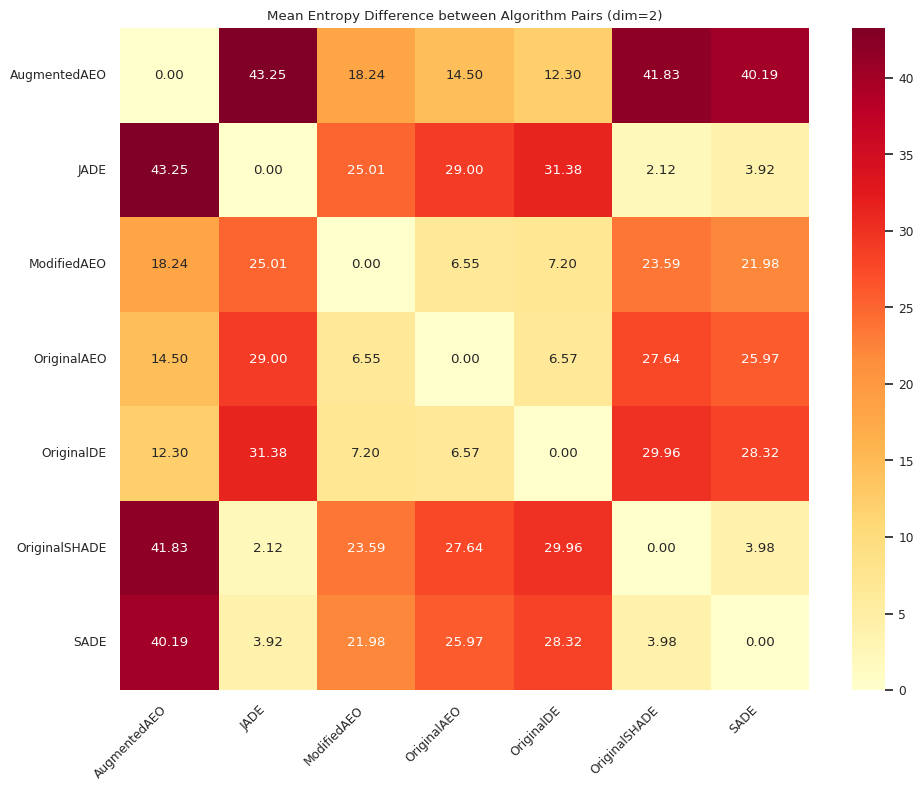

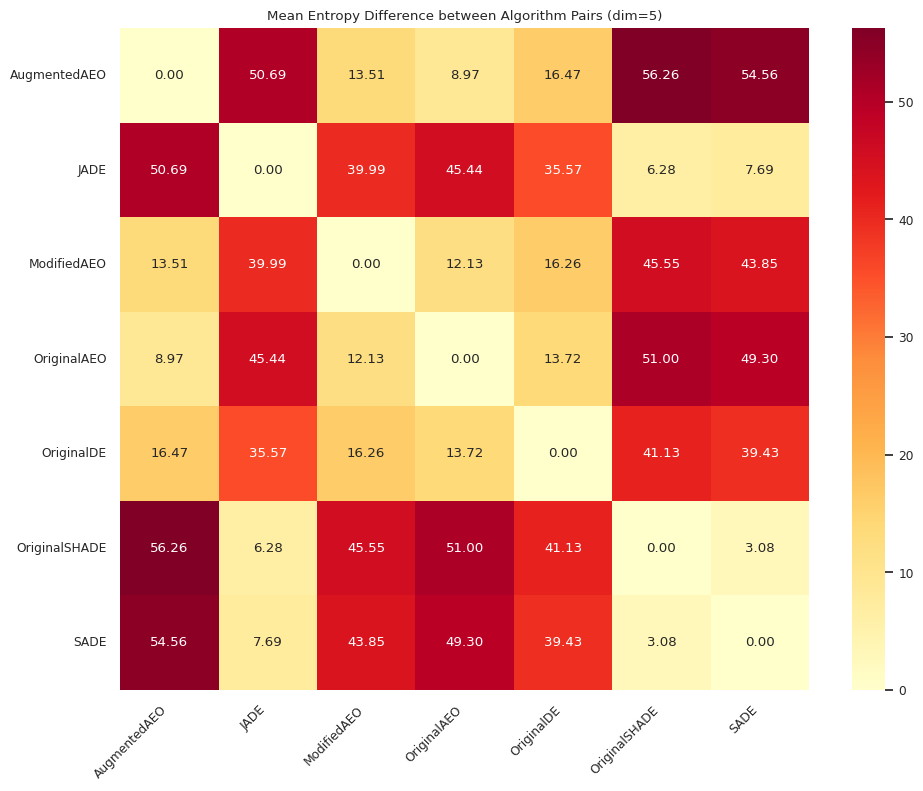

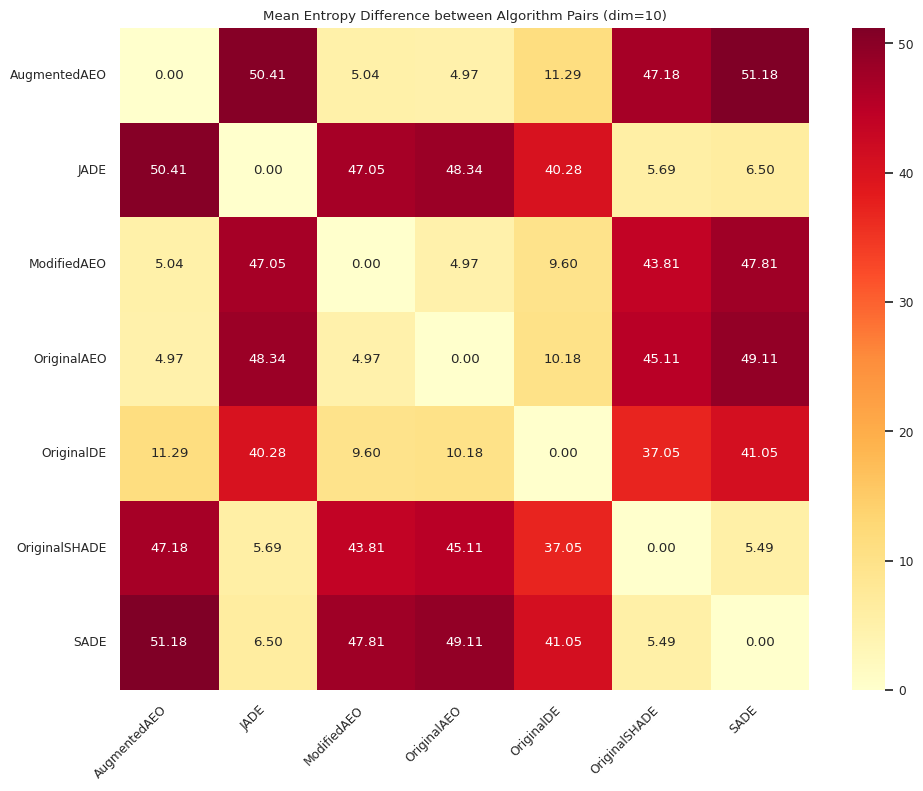

In [12]:
plot_entropy_diff(matrix2, dimension=2)
plot_entropy_diff(matrix5, dimension=5)
plot_entropy_diff(matrix10, dimension=10)

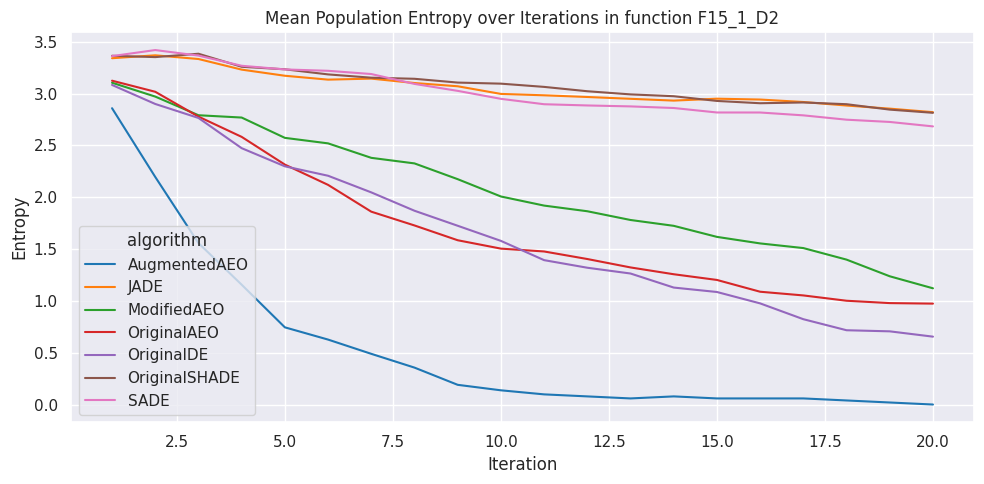

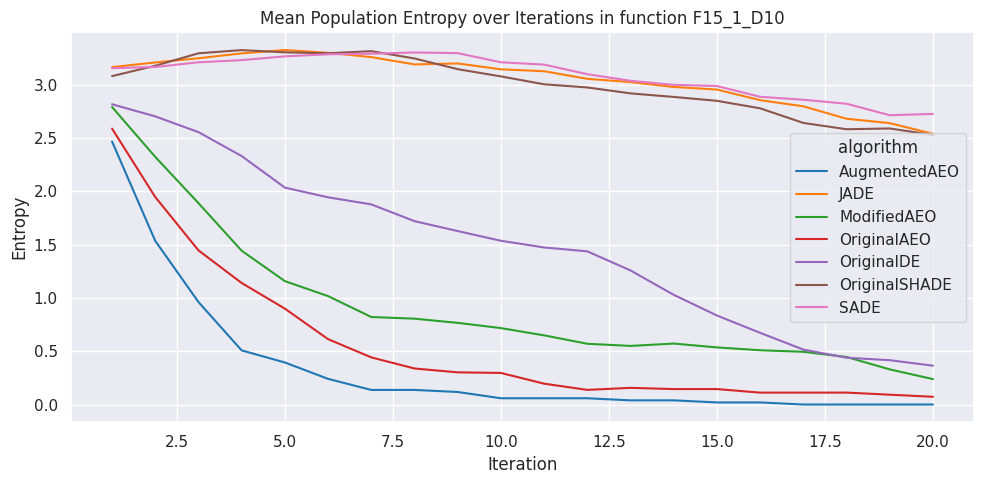

In [13]:
visualize_single_problem(15, 1, [2, 10])

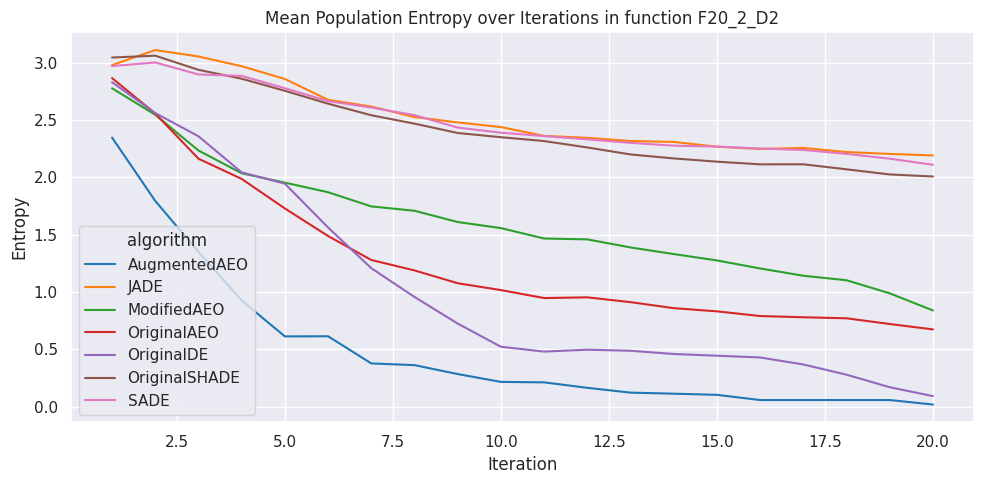

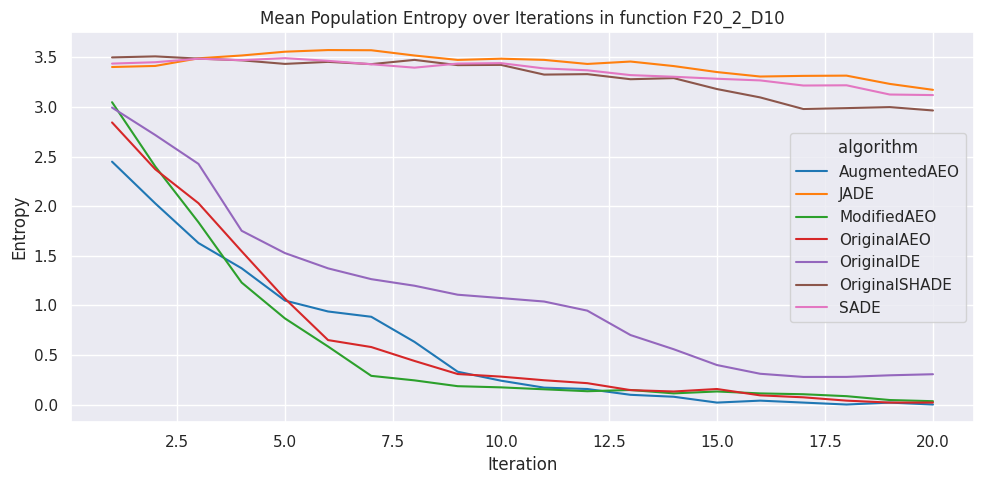

In [60]:
visualize_single_problem(20, 2, [2, 10])

In [14]:
def single_algorithm(function_class, algorithm):
    functions = FUNCTION_GROUPS[function_class]
    rows = []
    for f in functions:
        for dim in [2, 10]:
            input_dir = f'{INPUT_DIR}/dim_{dim}/F{f}_I1.csv'
            entropy = compute_entropy(input_dir, algorithms_of_interest=[algorithm])
            entropy['function'] = f
            entropy['dimension'] = dim
            rows.append(entropy)
    
    combined = pd.concat(rows, ignore_index=True)
    combined['label'] = 'F' + combined['function'].astype(str) + ' d' + combined['dimension'].astype(str)

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=combined, x='iteration', y='entropy', hue='label', palette='tab20', errorbar=None)
    plt.title(f'Entropy — {algorithm} on {function_class} functions')
    plt.xlabel('Iteration')
    plt.ylabel('Entropy')
    plt.tight_layout()
    plt.show()

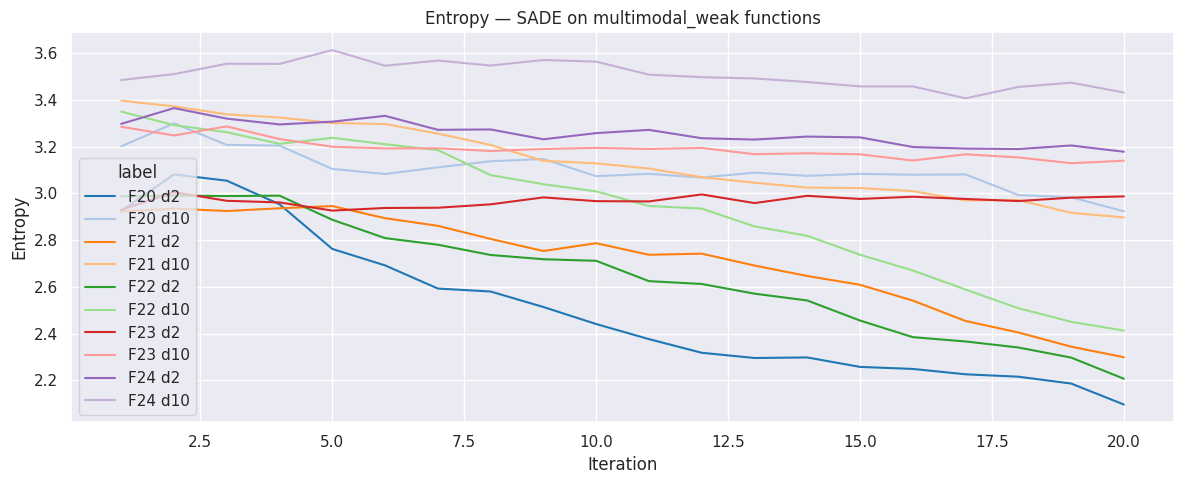

In [17]:
single_algorithm("multimodal_weak", "SADE")

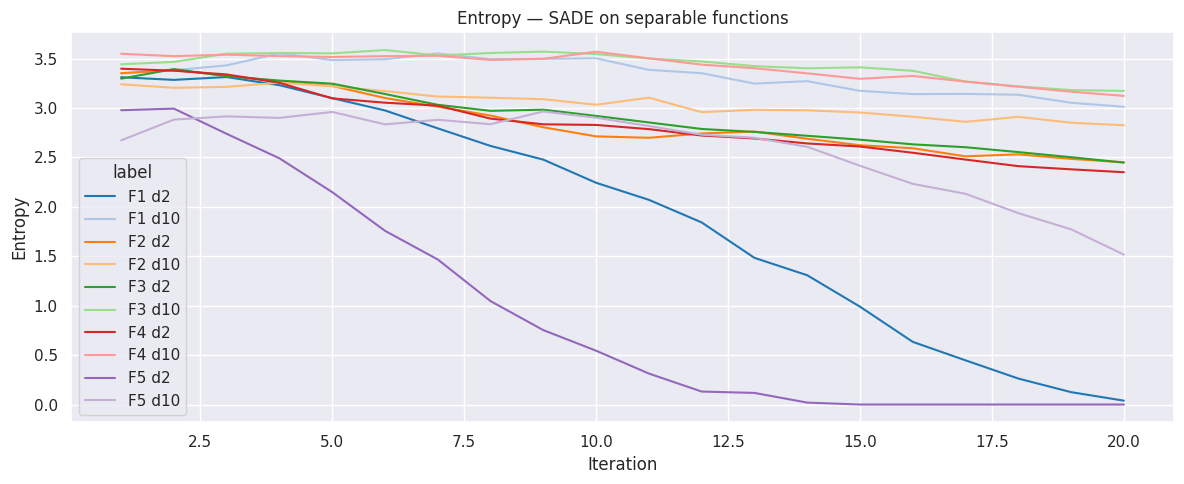

In [18]:
single_algorithm("separable", "SADE")

In [19]:
def get_best_fitness_per_iteration(filepath):
    df = pd.read_csv(filepath, header=None, names=['x1', 'x2', 'fitness', 'iteration', 'evaluations'])
    df['fitness'] = pd.to_numeric(df['fitness'], errors='coerce')
    df['iteration'] = pd.to_numeric(df['iteration'], errors='coerce')
    df = df.dropna(subset=['fitness', 'iteration'])
    best = df.groupby('iteration')['fitness'].min().reset_index()
    best.columns = ['iteration', 'best_fitness']
    return best

In [20]:
def get_best_fitness_all_runs(algorithm, function, instance, dim, n_runs=5):
    rows = []
    for run in range(1, n_runs + 1):
        filepath = f"outputs/dim_{dim}/{algorithm}/{function}_{instance}/trajectory_{run}.csv"
        best = get_best_fitness_per_iteration(filepath)
        best['run'] = run
        rows.append(best)
    return pd.concat(rows, ignore_index=True)

In [21]:
def plot_fitness_vs_entropy(algorithm, function, instance, dim):
    fitness = get_best_fitness_all_runs(algorithm, function, instance, dim)
    mean_fitness = fitness.groupby('iteration')['best_fitness'].mean().reset_index()

    entropy = compute_entropy(f'{INPUT_DIR}/dim_{dim}/F{function}_I{instance}.csv', 
                              algorithms_of_interest=[algorithm])
    mean_entropy = entropy.groupby('iteration')['entropy'].mean().reset_index()

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.plot(mean_fitness['iteration'], mean_fitness['best_fitness'], color='blue', label='Best fitness')
    ax2.plot(mean_entropy['iteration'], mean_entropy['entropy'], color='orange', label='Entropy')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Best fitness', color='blue')
    ax2.set_ylabel('Entropy', color='orange')
    plt.title(f'{algorithm} — F{function}_I{instance} dim{dim}')
    plt.tight_layout()
    plt.show()

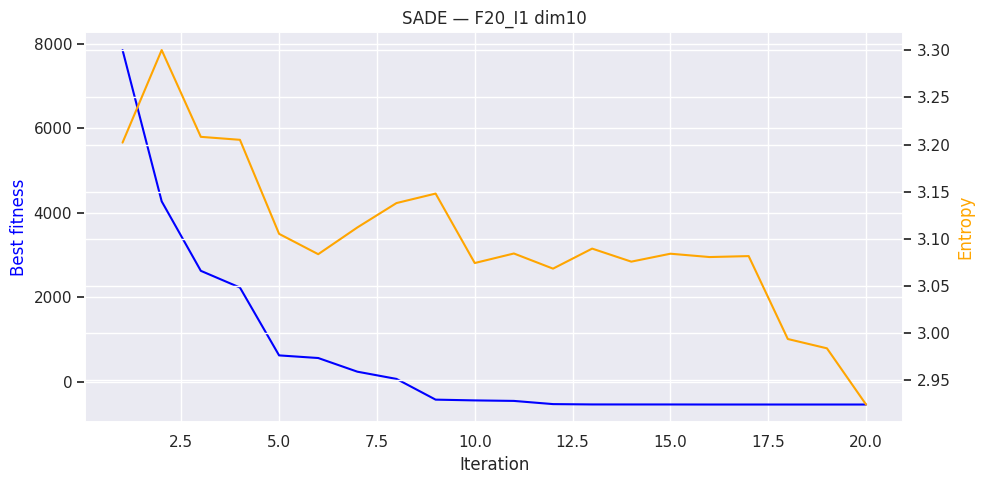

In [26]:
plot_fitness_vs_entropy("SADE", 20, 1, 10)

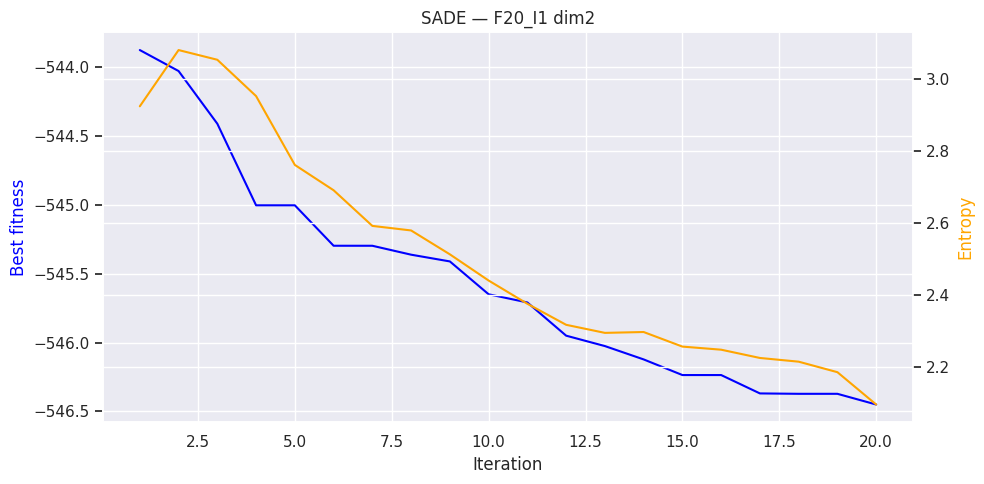

In [27]:
plot_fitness_vs_entropy("SADE", 20, 1, 2)